In [116]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [117]:
from google.colab import files
from PIL import Image

In [118]:
#Load the Fashion-MNIST dataset using TensorFlow/Keras.
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

In [119]:
#Number of training images
x_train.shape[0]

60000

In [120]:
#Number of testing images
x_test.shape[0]

10000

In [121]:
#Image dimensions
x_train.shape[1],x_train.shape[2]

(28, 28)

In [122]:
#Normalize the image pixel values.
x_train_norm=x_train.astype('float32')/255.0
x_test_norm=x_test.astype('float32')/255.0

In [123]:
#Reshape the images to make them compatible with CNN layers
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

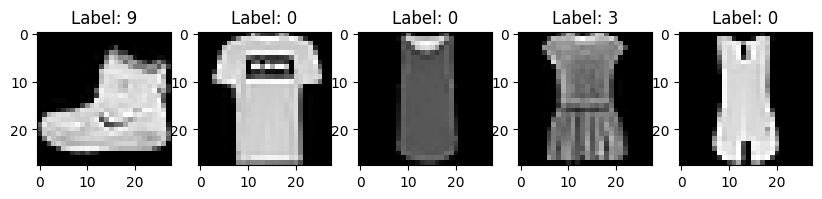

In [124]:
#Display at least five sample images along with their class labels.

plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
plt.show()

In [125]:
#Create a Convolutional Neural Network using TensorFlow/Keras.
model = models.Sequential([
    layers.Input(shape=(28, 28, 1), name="input_layer"),
    layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',name="conv_layer_1"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_1"),
    layers.Conv2D( filters=32,kernel_size=(3,3),activation='relu',name="conv_layer_2"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_2"),
    layers.Flatten(name="flatten_layer"),
    layers.Dense(units=64,activation='relu',name="hidden_layer_1"),
    layers.Dense(units=32,activation='relu',name="hidden_layer_2" ),
    layers.Dense(units=10,activation='softmax',name="output_layer")
])


In [126]:
#Compile the model
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [127]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,474 (228.41 KB)

 Trainable params: 58,474 (228.41 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
#part3
history = model.fit(x_train_norm,y_train,epochs=20,batch_size=32)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8066 - loss: 0.5297
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8702 - loss: 0.3587
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8866 - loss: 0.3105
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8967 - loss: 0.2806
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9064 - loss: 0.2557
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9131 - loss: 0.2348
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9192 - loss: 0.2197
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9228 - loss: 0.2063
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9276 - loss: 0.1942
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9323 - loss: 0.1838
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9354 - loss: 0.1723
Epoch 12/2

In [129]:
print("Number of Epochs:20", )
print("Batch Size: 32")
print("Final Training Accuracy:",history.history['accuracy'][-1])

Number of Epochs:20
Batch Size: 32
Final Training Accuracy: 0.9570833444595337


In [130]:
predictions = model.predict(x_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [131]:
predicted_labels = np.argmax(predictions, axis=1)


Predicted Class Labels for First 10 Test Images:



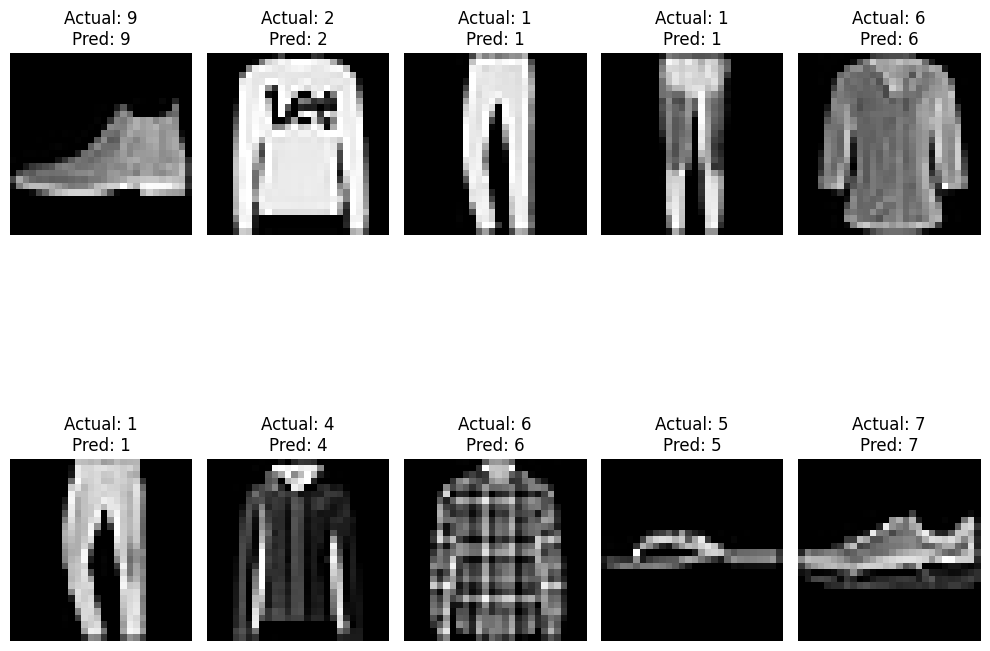

In [132]:
print("Predicted Class Labels for First 10 Test Images:\n")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [133]:
test_loss , test_accuracy = model.evaluate(x_test,y_test)
print('Test Accuracy:',test_accuracy)
print('Test loss:',test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7849 - loss: 159.7472
Test Accuracy: 0.7849000096321106
Test loss: 159.74716186523438


In [134]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_labels)
print("confusion metrics\n",cm)

confusion metrics
 [[883   0   9  20   3   0  77   0   8   0]
 [  4 975   0  11   4   0   3   0   3   0]
 [ 40   0 824   9  57   0  68   0   2   0]
 [ 19   2   6 929  18   0  24   0   2   0]
 [  2   0  52  29 856   0  60   0   1   0]
 [  1   0   0   0   0 982   0   9   4   4]
 [112   1  45  25  64   0 737   0  16   0]
 [  0   0   0   0   0  15   0 971   0  14]
 [  5   0   2   2   7   1   4   1 977   1]
 [  1   0   0   0   0   5   0  34   3 957]]


In [135]:
from sklearn.metrics import classification_report
print("Classification Report:\n")

print(classification_report(
    y_test,
    predicted_labels
))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1000
           1       1.00      0.97      0.99      1000
           2       0.88      0.82      0.85      1000
           3       0.91      0.93      0.92      1000
           4       0.85      0.86      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.76      0.74      0.75      1000
           7       0.96      0.97      0.96      1000
           8       0.96      0.98      0.97      1000
           9       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



1. Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image classification?

CNNs are more suitable for image classification because they automatically learn important features such as edges, shapes, and textures from images. They preserve the spatial relationships between pixels and use fewer parameters than ANNs, making them more efficient and accurate for image data.

2. What is the purpose of a Convolution layer?

The Convolution layer extracts important features from the input image by applying filters (kernels). It detects patterns such as edges, corners, and textures, which help the model recognize different objects in the image.

3. Why is Max Pooling used in CNNs?

Max Pooling reduces the size of the feature maps while keeping the most important information. This decreases computation, reduces overfitting, and makes the model faster and more efficient.

4. Why is the Flatten layer required before the Dense layers?

The Flatten layer converts the two-dimensional feature maps into a one-dimensional vector. This allows the Dense layers to process the extracted features and perform the final classification.

5. Why is the Softmax activation function used in the output layer?

The Softmax activation function converts the output values into probabilities that sum to 1. The class with the highest probability is selected as the predicted class, making it suitable for multi-class classification problems like Fashion-MNIST.

6. How does the Adam optimizer help in training the CNN?

The Adam optimizer updates the model's weights efficiently by using adaptive learning rates and momentum. It speeds up convergence, improves training performance, and often achieves higher accuracy with less manual tuning than traditional optimization methods.